# Tarea 2 - Clasificación de Ritmos Cardíacos con RNN/LSTM

Importamos las librerías necesarias para el proyecto.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from torchinfo import summary
import wandb
import kagglehub
import os

c:\Users\Enrique\anaconda3\envs\tarea2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuramos el dispositivo (GPU si está disponible, sino CPU).

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Descarga del Dataset

Descargamos el dataset de Heartbeat desde Kaggle.

In [3]:
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
print(f"Path to dataset files: {path}")

Path to dataset files: C:\Users\Enrique\.cache\kagglehub\datasets\shayanfazeli\heartbeat\versions\1


Cargamos los archivos CSV de entrenamiento y test.

In [4]:
train_df = pd.read_csv(os.path.join(path, 'mitbih_train.csv'), header=None)
test_df = pd.read_csv(os.path.join(path, 'mitbih_test.csv'), header=None)

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')

Train shape: (87554, 188)
Test shape: (21892, 188)


## 2. Análisis Exploratorio de Datos (EDA)

Separamos las características (X) de las etiquetas (y).

In [5]:
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values.astype(int)
X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values.astype(int)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (87554, 187)
y_train shape: (87554,)
X_test shape: (21892, 187)
y_test shape: (21892,)


Visualizamos la distribución de clases en el conjunto de entrenamiento.

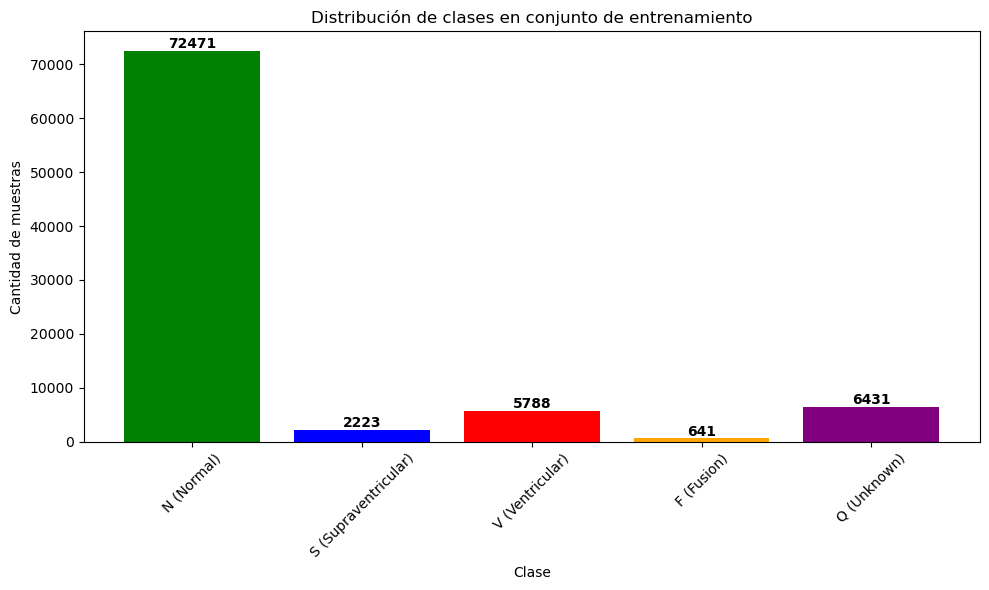

Porcentaje por clase:
N (Normal): 82.77%
S (Supraventricular): 2.54%
V (Ventricular): 6.61%
F (Fusion): 0.73%
Q (Unknown): 7.35%


In [6]:
class_names = ['N (Normal)', 'S (Supraventricular)', 'V (Ventricular)', 'F (Fusion)', 'Q (Unknown)']
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 6))
plt.bar(class_names, counts, color=['green', 'blue', 'red', 'orange', 'purple'])
plt.xlabel('Clase')
plt.ylabel('Cantidad de muestras')
plt.title('Distribución de clases en conjunto de entrenamiento')
plt.xticks(rotation=45)
for i, v in enumerate(counts):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('Porcentaje por clase:')
for i, name in enumerate(class_names):
    print(f'{name}: {counts[i]/len(y_train)*100:.2f}%')

Visualizamos un ejemplo de señal ECG por cada clase.

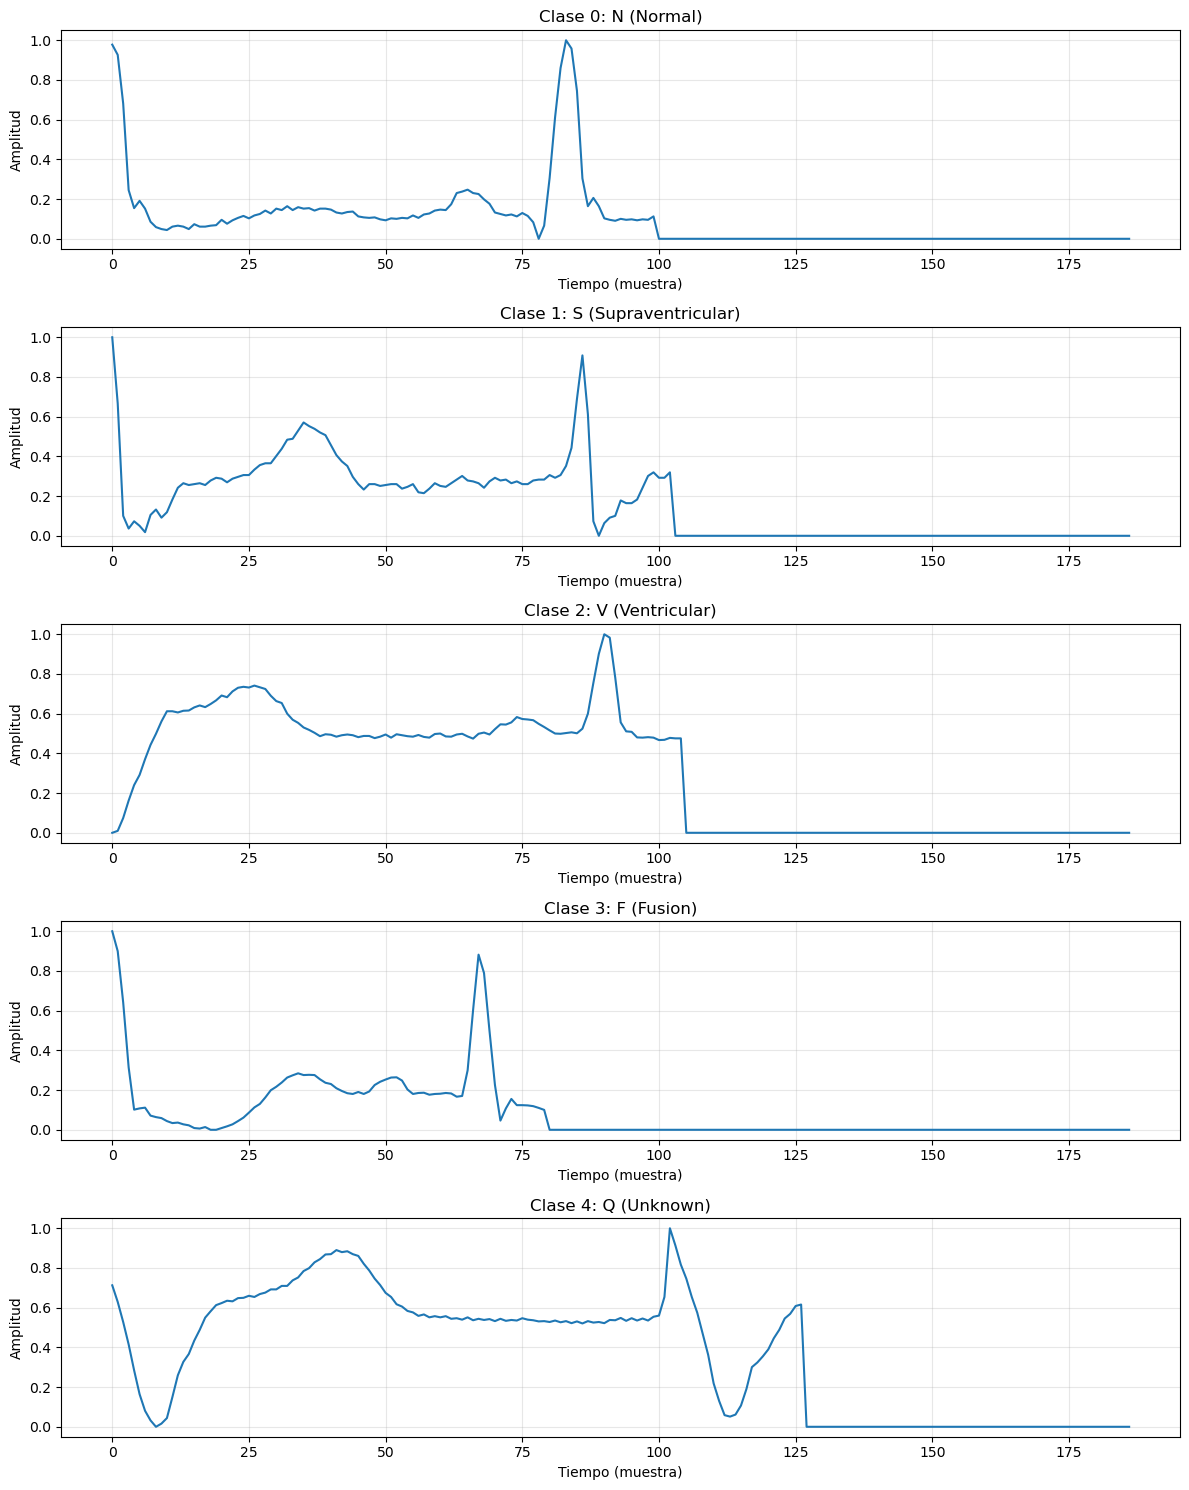

In [7]:
fig, axes = plt.subplots(5, 1, figsize=(12, 15))

for i in range(5):
    idx = np.where(y_train == i)[0][0]
    axes[i].plot(X_train[idx], linewidth=1.5)
    axes[i].set_title(f'Clase {i}: {class_names[i]}')
    axes[i].set_xlabel('Tiempo (muestra)')
    axes[i].set_ylabel('Amplitud')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Analizamos el rango de valores de los datos.

In [8]:
print(f'Rango de valores:')
print(f'Min: {X_train.min():.4f}')
print(f'Max: {X_train.max():.4f}')
print(f'Media: {X_train.mean():.4f}')
print(f'Std: {X_train.std():.4f}')

Rango de valores:
Min: 0.0000
Max: 1.0000
Media: 0.1743
Std: 0.2263


## 3. Preprocesamiento de Datos

**Decisiones de preprocesamiento:**
- Los datos ya están normalizados en el rango [0, 1] aproximadamente
- Las clases están muy desbalanceadas (clase 0 domina con ~83%)
- Cada latido tiene 187 valores temporales que trataremos como secuencia
- Dividiremos el conjunto de entrenamiento en train/validation (80/20)

Definimos la clase Dataset personalizada para PyTorch.

In [9]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X).unsqueeze(-1)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Creamos los datasets y dividimos en train/validation (80/20).

In [10]:
full_train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f'Train size: {len(train_dataset)}')
print(f'Validation size: {len(val_dataset)}')
print(f'Test size: {len(test_dataset)}')

Train size: 70043
Validation size: 17511
Test size: 21892


Creamos los DataLoaders para cargar los datos en batches.

In [11]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_batch, sample_labels = next(iter(train_loader))
print(f'Batch shape: {sample_batch.shape}')
print(f'Labels shape: {sample_labels.shape}')

Batch shape: torch.Size([64, 187, 1])
Labels shape: torch.Size([64])


## 4. Arquitectura del Modelo LSTM

Definimos la arquitectura del clasificador LSTM.

In [12]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        out, (hidden, cell) = self.lstm(x)
        hidden = hidden[-1]
        hidden = self.dropout(hidden)
        return self.fc(hidden)

Creamos una instancia del modelo y mostramos su resumen.

In [13]:
INPUT_SIZE = 1
HIDDEN_DIM = 64
NUM_LAYERS = 2
NUM_CLASSES = 5
DROPOUT = 0.0

model = LSTMClassifier(INPUT_SIZE, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES, DROPOUT).to(device)
summary(model, input_size=(BATCH_SIZE, 187, INPUT_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
LSTMClassifier                           [64, 5]                   --
├─LSTM: 1-1                              [64, 187, 64]             50,432
├─Dropout: 1-2                           [64, 64]                  --
├─Linear: 1-3                            [64, 5]                   325
Total params: 50,757
Trainable params: 50,757
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 603.59
Input size (MB): 0.05
Forward/backward pass size (MB): 6.13
Params size (MB): 0.20
Estimated Total Size (MB): 6.38

## 5. Funciones de Entrenamiento y Evaluación

Definimos la función para entrenar una época.

In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * X.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y).sum().item()
        total += y.size(0)
    
    return total_loss / total, correct / total

Definimos la función para evaluar el modelo.

In [15]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)
    
    return total_loss / total, correct / total

Definimos la función principal de entrenamiento con logging a wandb.

In [16]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, experiment_name):
    wandb.init(project='Taller de IA - Tarea 2', name=experiment_name, reinit=True)
    wandb.watch(model)
    
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    best_val_acc = 0
    best_model_state = None
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        })
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
        
        print(f'Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    
    wandb.finish()
    
    return train_losses, train_accs, val_losses, val_accs, best_model_state

## 6. Experimentos con Wandb

Iniciamos sesión en Weights & Biases.

In [17]:
wandb.login()

wandb: Currently logged in as: eo214205 (eo214205-ort) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### Entrenamiento del Modelo

Entrenamos el modelo LSTM con la configuración inicial (sin regularización).

In [18]:
model = LSTMClassifier(input_size=1, hidden_dim=64, num_layers=2, num_classes=5, dropout=0.0).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses, train_accs, val_losses, val_accs, best_model_state = train_model(
    model, train_loader, val_loader, criterion, optimizer, device, epochs=20, experiment_name='Corrida 1 - Sin regularización (baseline)'
)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 1/20 - Train Loss: 0.6698, Train Acc: 0.8254, Val Loss: 0.6522, Val Acc: 0.8292
Epoch 2/20 - Train Loss: 0.6526, Train Acc: 0.8273, Val Loss: 0.6493, Val Acc: 0.8289
Epoch 3/20 - Train Loss: 0.6289, Train Acc: 0.8325, Val Loss: 0.6106, Val Acc: 0.8437
Epoch 4/20 - Train Loss: 0.6164, Train Acc: 0.8420, Val Loss: 0.6115, Val Acc: 0.8436
Epoch 5/20 - Train Loss: 0.6270, Train Acc: 0.8385, Val Loss: 0.6256, Val Acc: 0.8358
Epoch 6/20 - Train Loss: 0.6290, Train Acc: 0.8361, Val Loss: 0.6238, Val Acc: 0.8402
Epoch 7/20 - Train Loss: 0.6238, Train Acc: 0.8387, Val Loss: 0.6174, Val Acc: 0.8422
Epoch 8/20 - Train Loss: 0.6308, Train Acc: 0.8371, Val Loss: 0.6211, Val Acc: 0.8354
Epoch 9/20 - Train Loss: 0.6149, Train Acc: 0.8411, Val Loss: 0.6090, Val Acc: 0.8436
Epoch 10/20 - Train Loss: 0.6099, Train Acc: 0.8417, Val Loss: 0.5913, Val Acc: 0.8438
Epoch 11/20 - Train Loss: 0.6114, Train Acc: 0.8411, Val Loss: 0.5932, Val Acc: 0.8428
Epoch 12/20 - Train Loss: 0.5947, Train Acc: 0.8422,

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▁▂▂▂▂▂▂▂▂▂▂▃▅▇▇████
train_loss,██▇▇▇▇▇▇▇▇▇▇▆▄▃▂▂▁▁▁
val_acc,▁▁▂▂▂▂▂▁▂▂▂▂▄▆▆▇████
val_loss,██▇▇▇▇▇▇▇▇▇▇▅▃▃▂▂▁▁▁
epoch,20
train_acc,0.92435
train_loss,0.29434
val_acc,0.92456
val_loss,0.29544


## 7. Visualización del Entrenamiento

Graficamos las curvas de entrenamiento.

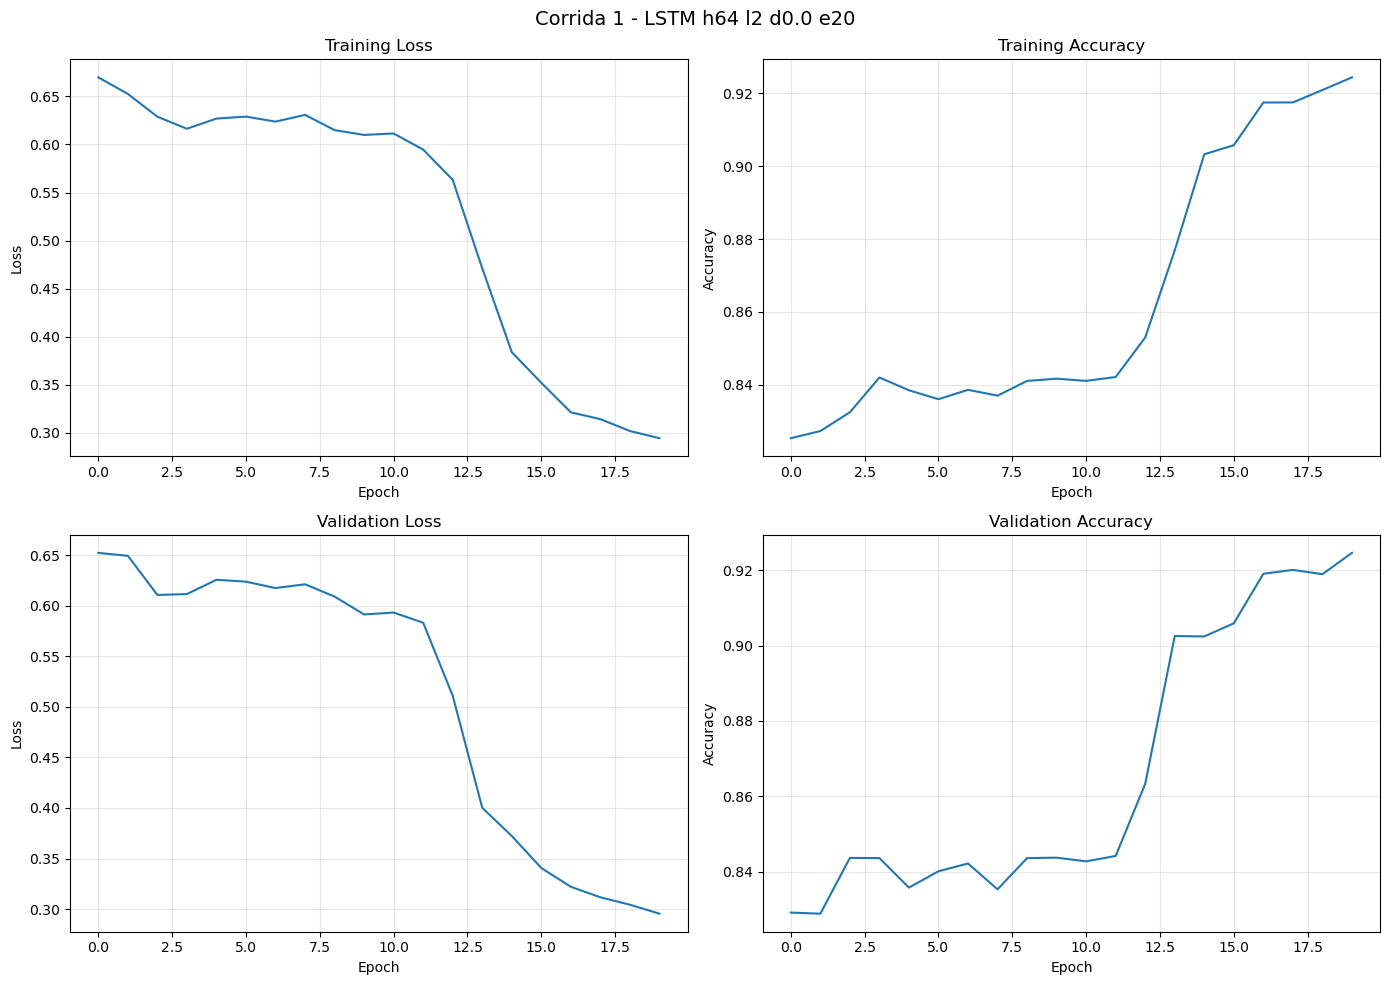

Mejor accuracy de validación: 0.9246


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(train_losses)
axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(train_accs)
axes[0, 1].set_title('Training Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(val_losses)
axes[1, 0].set_title('Validation Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(val_accs)
axes[1, 1].set_title('Validation Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Corrida 1 - LSTM h64 l2 d0.0 e20', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Mejor accuracy de validación: {max(val_accs):.4f}')

## 8. Link a Wandb

https://wandb.ai/eo214205-ort/Taller%20de%20IA%20-%20Tarea%202

## 9. Evaluación Final en Test Set

In [20]:
model.load_state_dict(best_model_state)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        outputs = model(X)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

Calculamos las métricas globales requeridas.

In [21]:
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')

print('=== MÉTRICAS GLOBALES (MACRO) ===')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

=== MÉTRICAS GLOBALES (MACRO) ===
Accuracy: 0.9254
Precision: 0.5484
Recall: 0.4901
F1-Score: 0.5126


c:\Users\Enrique\anaconda3\envs\tarea2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Mostramos el reporte de clasificación detallado por clase.

In [22]:
print('\n=== REPORTE DE CLASIFICACIÓN POR CLASE ===')
target_names = ['N (Normal)', 'S (Supra)', 'V (Ventr)', 'F (Fusion)', 'Q (Unknown)']
print(classification_report(all_labels, all_preds, target_names=target_names))


=== REPORTE DE CLASIFICACIÓN POR CLASE ===
              precision    recall  f1-score   support

  N (Normal)       0.93      0.99      0.96     18118
   S (Supra)       0.00      0.00      0.00       556
   V (Ventr)       0.88      0.58      0.70      1448
  F (Fusion)       0.00      0.00      0.00       162
 Q (Unknown)       0.93      0.88      0.90      1608

    accuracy                           0.93     21892
   macro avg       0.55      0.49      0.51     21892
weighted avg       0.89      0.93      0.91     21892



c:\Users\Enrique\anaconda3\envs\tarea2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Enrique\anaconda3\envs\tarea2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Enrique\anaconda3\envs\tarea2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

Visualizamos la matriz de confusión.

## 10. Conclusiones

